# 4.3 - EWC

Penalise moving the weights that mattered for previous tasks.

Memory: Fisher and theta*, no stored data.

Tune EWC_LAMBDA from the printed CE and EWC values: EWC should be 5-20% of CE.

## **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "embeddings"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [ ]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "xx"

## **Download DATASET**

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Drive mounted.
Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
ULAL_DATASET_ROOT = /kaggle/input/ucf101-action-recognition/
ULAL_OUTPUT_ROOT  = /kaggle/working/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
GPU       : Tesla T4 (15.6 GB)
Classes   : base=10 t1=10 t2=10 t3=10 t4=10


42

## **Preprocess data**

In [ ]:
# rebuild clip roots clean (a prior run may have written the leaky split here)
for _root in [cfg.BASE_ROOT, cfg.TASK1_ROOT, cfg.TASK2_ROOT]:
    if os.path.isdir(_root):
        shutil.rmtree(_root)

# BASE
base_split = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
preprocess_group_split(base_split, cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT)

# TASK 1
task1_split = build_group_split(cfg.TASK_1, train_groups=18, val_groups=3)
preprocess_group_split(task1_split, cfg.TASK_1, output_root=cfg.TASK1_ROOT)

# TASK 2
task2_split = build_group_split(cfg.TASK_2, train_groups=18, val_groups=3)
preprocess_group_split(task2_split, cfg.TASK_2, output_root=cfg.TASK2_ROOT)

In [ ]:
cfg.SELECTED_CLASSES

['PlayingTabla',
 'PommelHorse',
 'JumpingJack',
 'PushUps',
 'PoleVault',
 'HorseRace',
 'HighJump',
 'Drumming',
 'HorseRiding',
 'Diving']

In [7]:
print(cfg.SELECTED_CLASSES + cfg.TASK_1)

['PlayingTabla', 'PommelHorse', 'JumpingJack', 'PushUps', 'PoleVault', 'HorseRace', 'HighJump', 'Drumming', 'HorseRiding', 'Diving', 'ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BlowDryHair', 'BlowingCandles', 'BodyWeightSquats', 'Bowling']


In [ ]:
# The cache fixes the label space, so it is built once here for all tasks.
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2

class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}

print(f"\nclass_to_idx:\n{class_to_idx}")


class_to_idx:
{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14, 'BandMarching': 15, 'BlowDryHair': 16, 'BlowingCandles': 17, 'BodyWeightSquats': 18, 'Bowling': 19, 'BoxingPunchingBag': 20, 'BoxingSpeedBag': 21, 'BrushingTeeth': 22, 'CliffDiving': 23, 'CricketBowling': 24, 'CricketShot': 25, 'CuttingInKitchen': 26, 'FieldHockeyPenalty': 27, 'Haircut': 28, 'SoccerPenalty': 29}


## **Create Loaders**

In [9]:
CACHE, LSTM_STATE, META = load_feature_cache(cfg.FEAT_CACHE)
check_cache_labels(META, ALL_CLASSES_LIST)

TASK_CLASSES = [cfg.SELECTED_CLASSES, cfg.TASK_1, cfg.TASK_2]
TASK_ROOTS   = [cfg.BASE_ROOT, cfg.TASK1_ROOT, cfg.TASK2_ROOT]
TASK_NAMES   = ["Base", "Task1", "Task2"]

base_test_loader  = emb_loaders(CACHE, [0], "test")[1]
task1_test_loader = emb_loaders(CACHE, [1], "test")[1]
task2_test_loader = emb_loaders(CACHE, [2], "test")[1]

combined_test_loader  = emb_loaders(CACHE, [0, 1], "test")[1]
combined_test_loader2 = emb_loaders(CACHE, [0, 1, 2], "test")[1]

base_train,  base_y   = task_split(CACHE, 0, "train")
base_val,    base_vy  = task_split(CACHE, 0, "val")
task1_train, task1_y  = task_split(CACHE, 1, "train")
task1_val,   task1_vy = task_split(CACHE, 1, "val")
task2_train, task2_y  = task_split(CACHE, 2, "train")
task2_val,   task2_vy = task_split(CACHE, 2, "val")

print(f"base  test {len(base_test_loader.dataset)}")
print(f"task1 test {len(task1_test_loader.dataset)}")
print(f"task2 test {len(task2_test_loader.dataset)}")

Loaded 9 tensors, 526 MB in RAM
  per clip: (16, 2048)
base  test 212
task1 test 217
task2 test 226


## **Upload Model**

In [10]:
ARM_KEY  = "ewc"
ARM_NAME = "EWC"
EWC_LAMBDA = 1.0
ARM_CONFIG = {"mechanism": "ewc", "ewc_lambda": EWC_LAMBDA}

CL_EPOCHS, CL_LR, CL_WD, CL_BATCH, CL_LS = 15, 5e-4, 0.03, 32, 0.10

head_base = load_or_train_base_head(
    f"{cfg.CKPT_DIR}/head_base.pt", CACHE, LSTM_STATE, len(cfg.SELECTED_CLASSES), device,
    epochs=CL_EPOCHS, lr=CL_LR, wd=CL_WD, batch_size=CL_BATCH, label_smoothing=CL_LS,
)

Loaded base head <- /content/drive/MyDrive/apai/checkpoints/head_base.pt


In [11]:
fisher, optpar = {}, {}
compute_fisher(ModelWrapper(head_base).to(device),
               emb_loader(base_train, base_y, CL_BATCH), device, 0, fisher, optpar)

head_task1 = expand_head(copy.deepcopy(head_base), len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1))
model_task1 = ModelWrapper(head_task1).to(device)

fisher, optpar = pad_fisher_after_expand(fisher, optpar, model_task1)

[Fisher] task_id=0 | samples=953 | mean=0.111603
  [pad] original_model.classifier.weight: torch.Size([10, 256]) -> torch.Size([20, 256])
  [pad] original_model.classifier.bias: torch.Size([10]) -> torch.Size([20])


In [12]:
results_baseline = evaluate_all_tasks(
    model            = model_task1,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader],
    combined_loaders = [combined_test_loader],
)

  base             -> Acc=0.9151  Loss=0.9677
  task1_only       -> Acc=0.0138  Loss=3.1141
  combined_t1      -> Acc=0.4592  Loss=2.0534


In [ ]:
print(f"head_task1 classifier: in={head_task1.classifier.in_features}  out={head_task1.classifier.out_features}")

head_task1 classifier: in=256  out=20


## **Task One**

In [14]:
set_seed(cfg.SEED)

head_task1, train_task1 = train_task(
    head_task1, task1_train, task1_y, task1_val, task1_vy, device,
    epochs=CL_EPOCHS, lr=CL_LR, wd=CL_WD, batch_size=CL_BATCH, label_smoothing=CL_LS,
    fisher=fisher, optpar=optpar, ewc_lambda=EWC_LAMBDA,
    tag=ARM_KEY,
)
model_task1 = ModelWrapper(head_task1).to(device)

Epoch [1/15] | Train Acc: 0.6923 Loss: 1.4766 | Val Acc: 0.8039 Loss: 0.7225
  [ewc] ep 01/15 | CE 1.4766 | EWC 0.0316
Epoch [2/15] | Train Acc: 0.9498 Loss: 0.7766 | Val Acc: 0.8301 Loss: 0.6549
Epoch [3/15] | Train Acc: 0.9904 Loss: 0.6734 | Val Acc: 0.8562 Loss: 0.5959
Epoch [4/15] | Train Acc: 1.0000 Loss: 0.6382 | Val Acc: 0.8431 Loss: 0.6242
Epoch [5/15] | Train Acc: 1.0000 Loss: 0.6236 | Val Acc: 0.8431 Loss: 0.6510
Epoch [6/15] | Train Acc: 1.0000 Loss: 0.6189 | Val Acc: 0.8366 Loss: 0.6325
Epoch [7/15] | Train Acc: 1.0000 Loss: 0.6155 | Val Acc: 0.8431 Loss: 0.6358
Epoch [8/15] | Train Acc: 1.0000 Loss: 0.6130 | Val Acc: 0.8366 Loss: 0.6890
Epoch [9/15] | Train Acc: 1.0000 Loss: 0.6126 | Val Acc: 0.8431 Loss: 0.6740
Epoch [10/15] | Train Acc: 1.0000 Loss: 0.6108 | Val Acc: 0.8366 Loss: 0.6886
Epoch [11/15] | Train Acc: 1.0000 Loss: 0.6105 | Val Acc: 0.8431 Loss: 0.6729
Epoch [12/15] | Train Acc: 1.0000 Loss: 0.6098 | Val Acc: 0.8431 Loss: 0.6776
Epoch [13/15] | Train Acc: 1.00

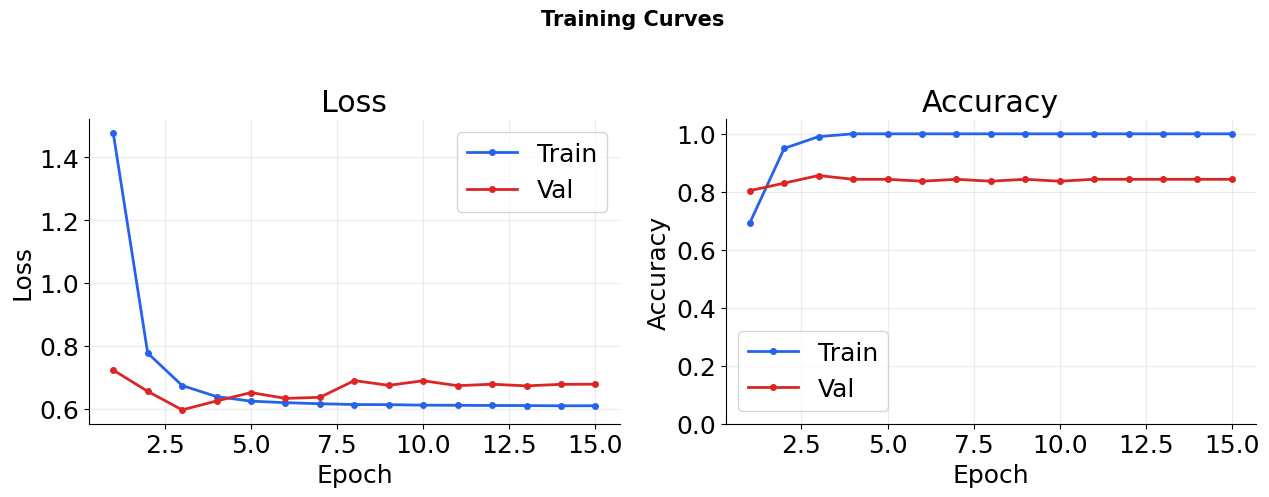

In [15]:
plot_training_results(train_task1)

In [16]:
results_after_t1 = evaluate_all_tasks(
    model            = model_task1,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader],
    combined_loaders = [combined_test_loader],
)

  base             -> Acc=0.0802  Loss=3.0830
  task1_only       -> Acc=0.9124  Loss=0.4326
  combined_t1      -> Acc=0.5012  Loss=1.7424


Running Inference on Test Set...


Test Accuracy: 0.5012


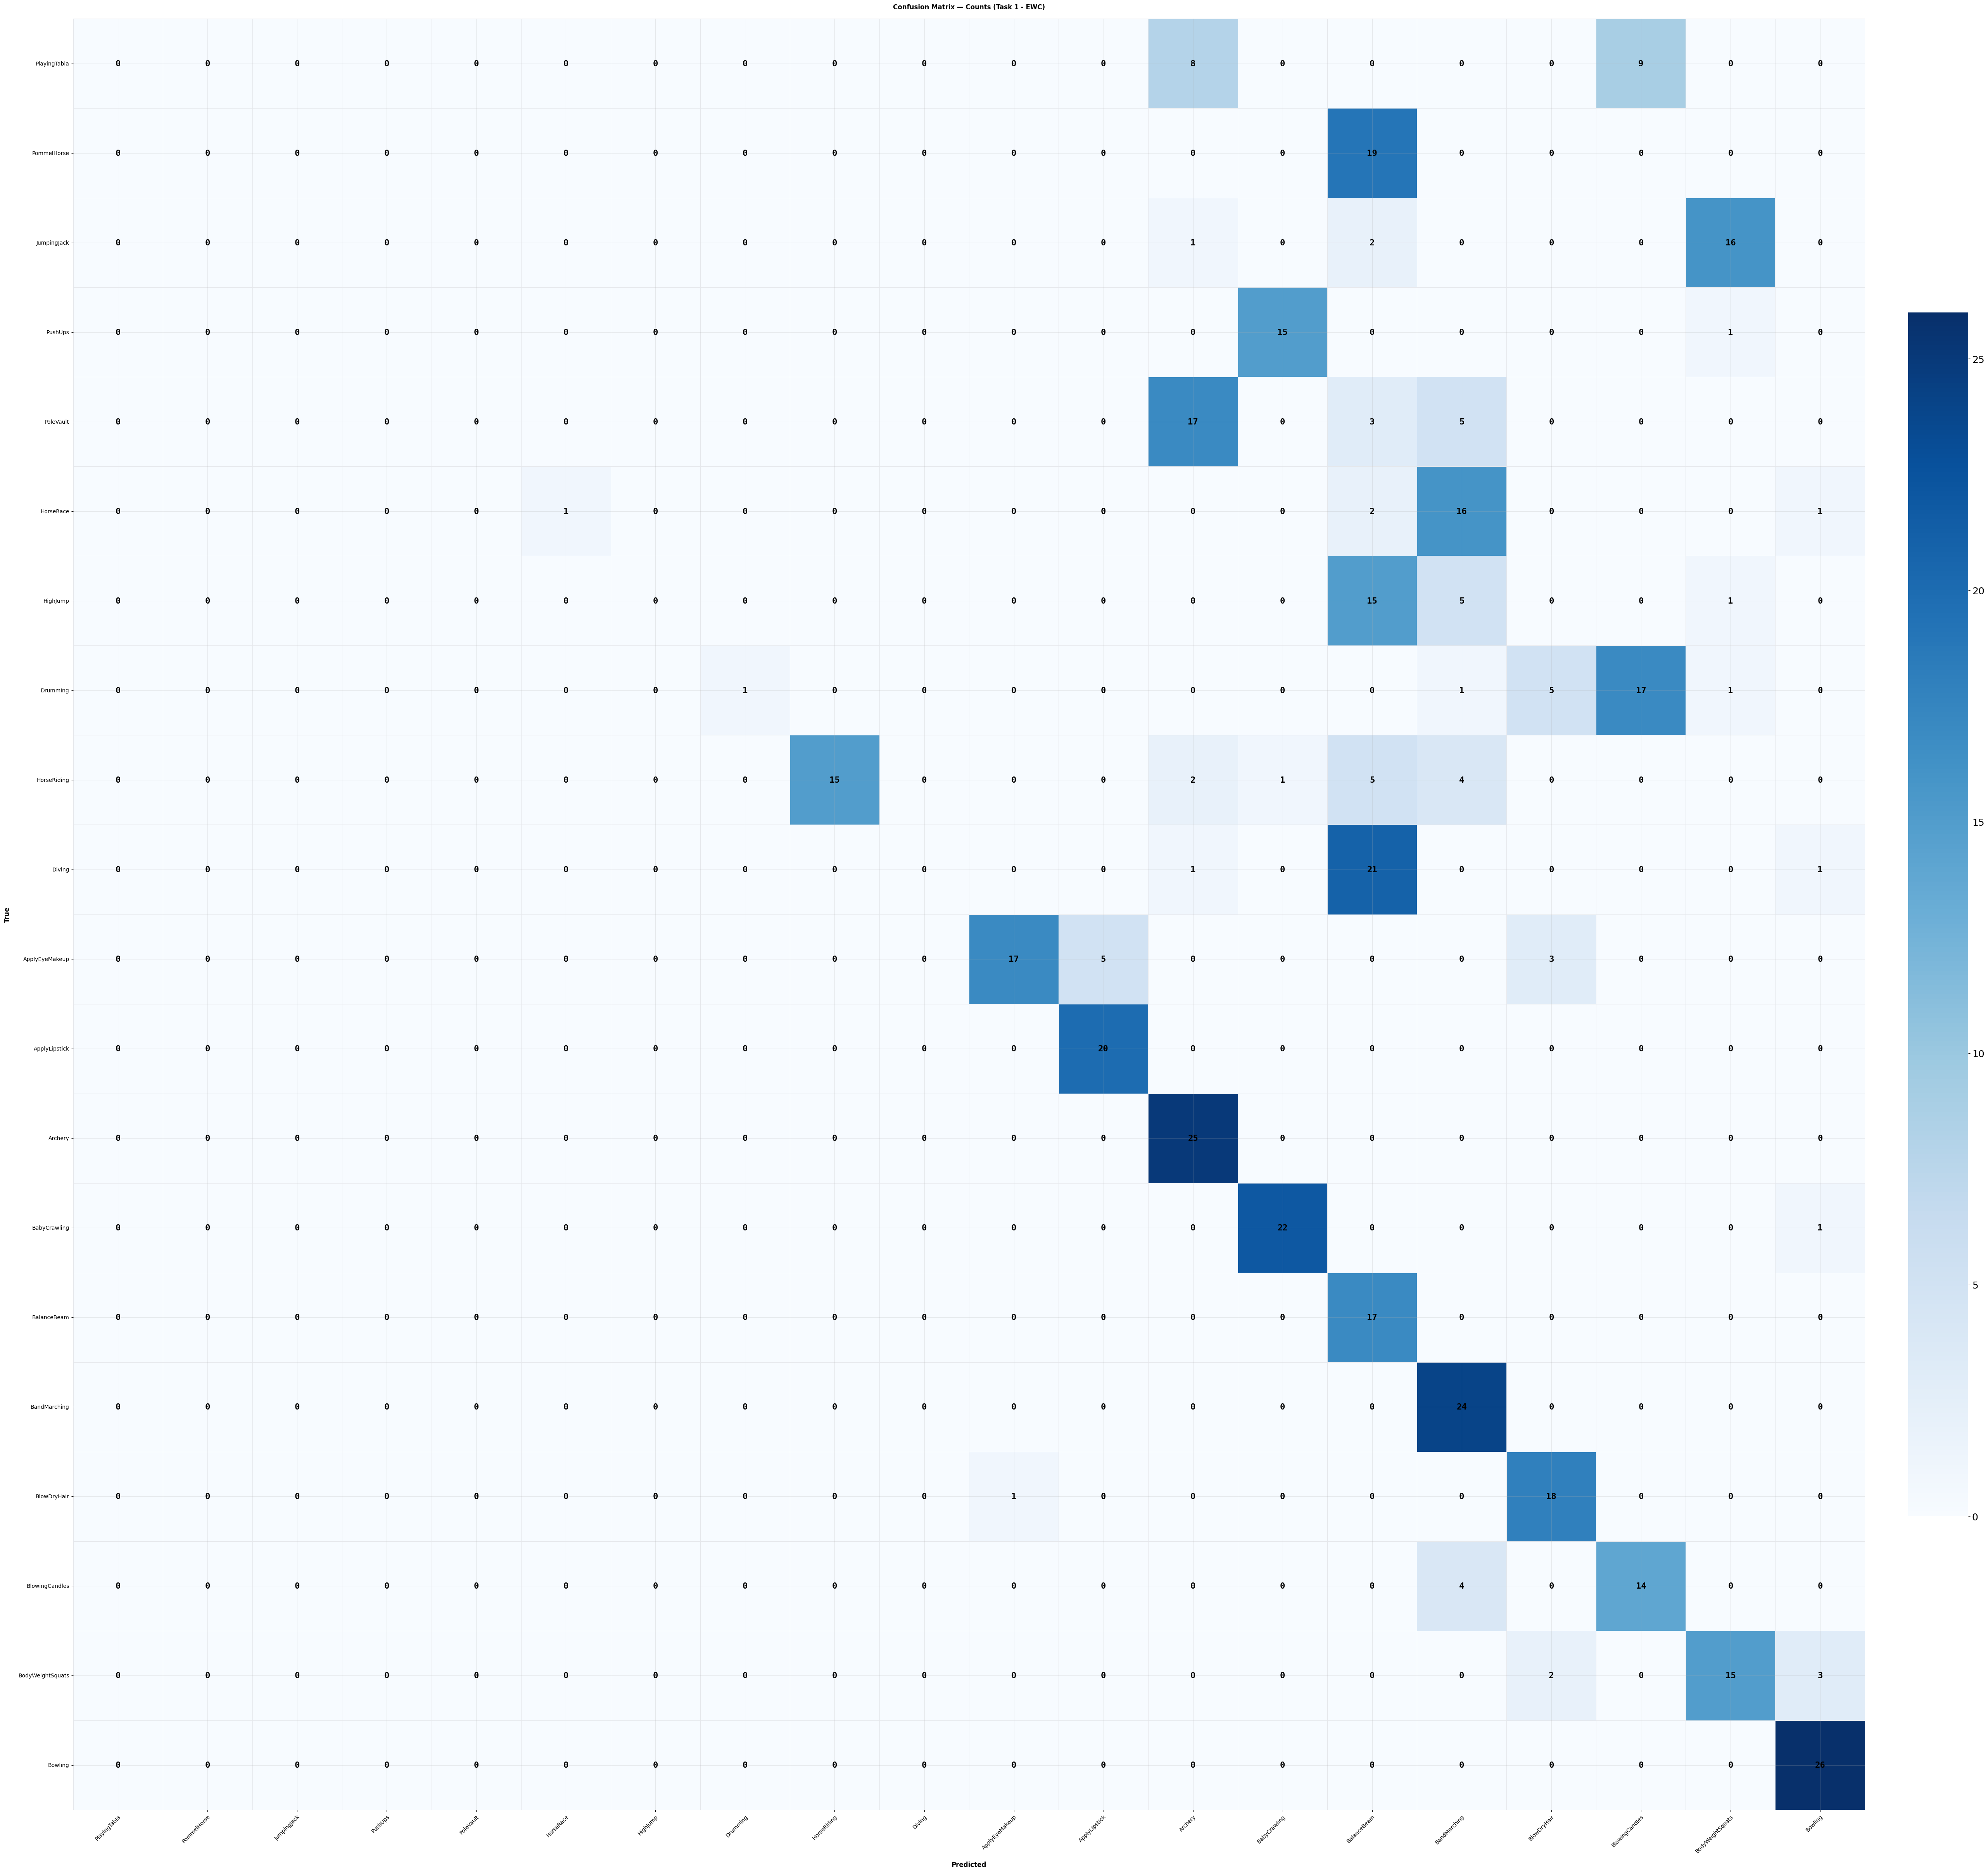

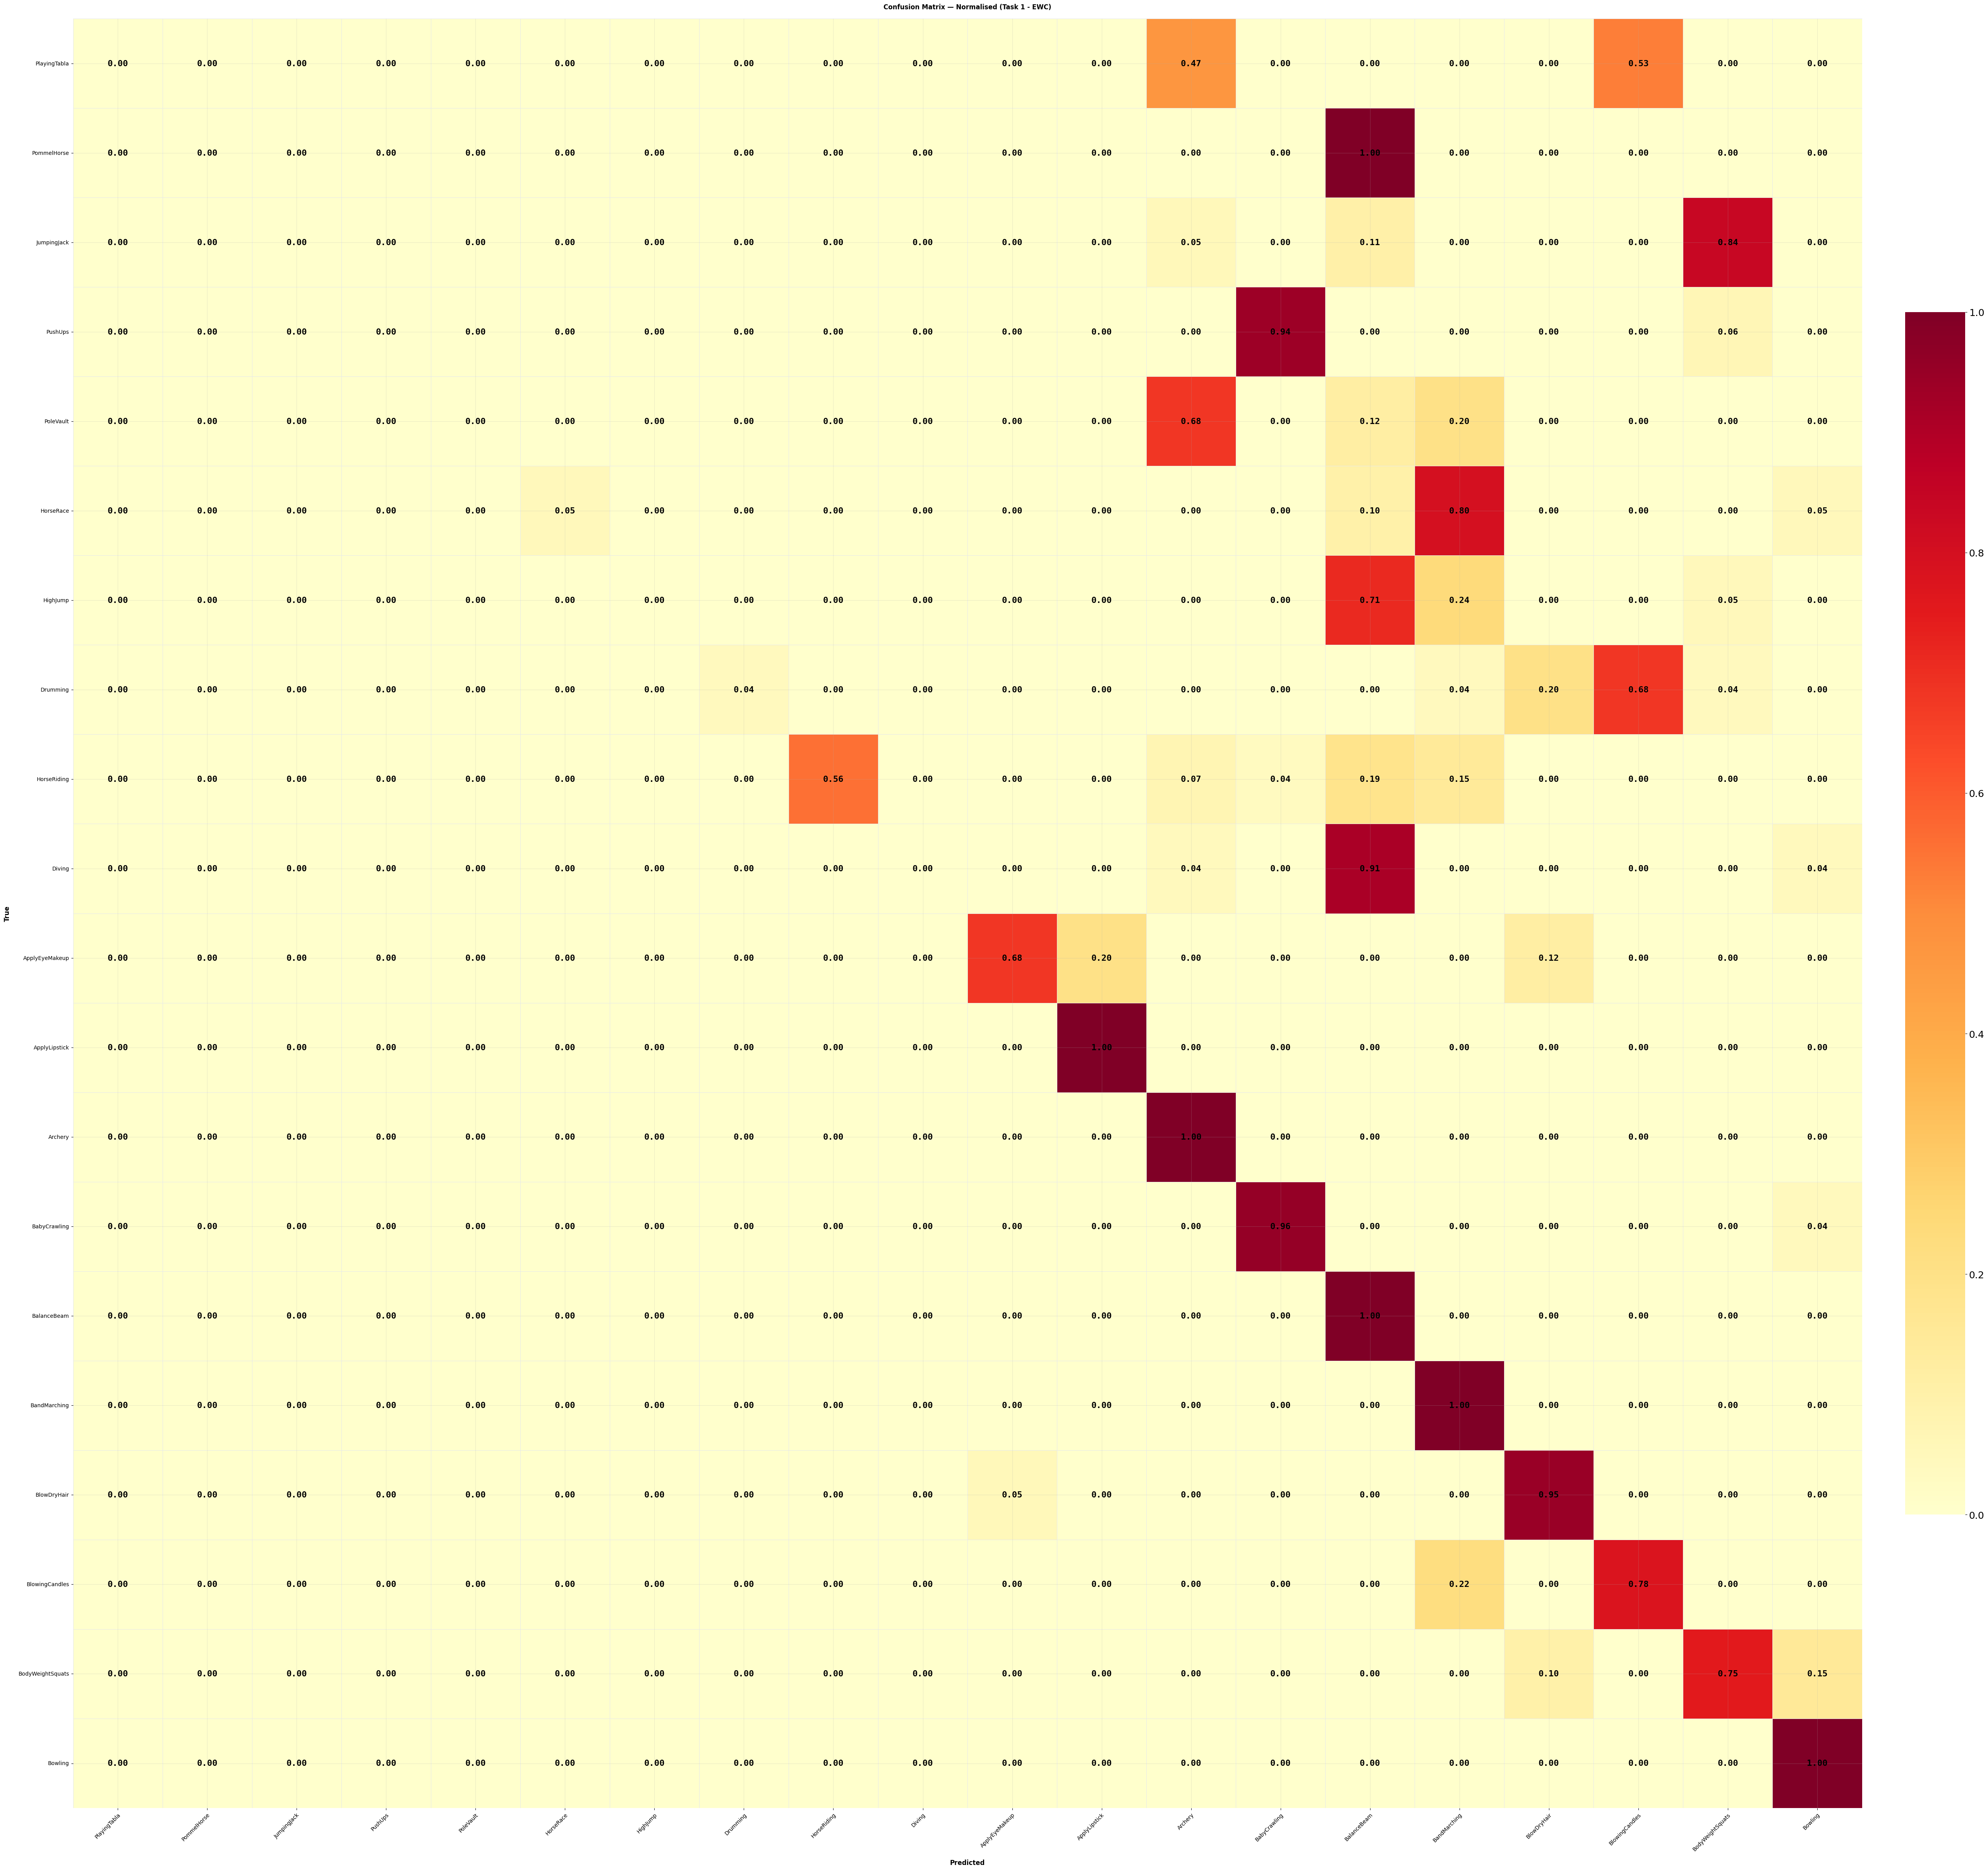

In [17]:
_, all_preds, all_labels = test_model(model_task1, combined_test_loader, device)

plot_confusion_matrix(
    all_labels, all_preds,
    num_classes  = len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1),
    classes_list = ALL_CLASSES_LIST,
    name         = f"Task 1 - {ARM_NAME}",
)

In [18]:
print_detailed_metrics(
    all_labels   = all_labels,
    all_preds    = all_preds,
    num_classes  = len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1),
    classes_list = ALL_CLASSES_LIST,
    split_old    = (0, len(cfg.SELECTED_CLASSES)),
    split_new    = (len(cfg.SELECTED_CLASSES), len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1)),
)


METRICS FOR 20 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.5012
  Precision : 0.4619
  Recall    : 0.5012
  F1-Score  : 0.3971

PER-CLASS REPORT 
                  precision    recall  f1-score   support

    PlayingTabla       0.00      0.00      0.00        17
     PommelHorse       0.00      0.00      0.00        19
     JumpingJack       0.00      0.00      0.00        19
         PushUps       0.00      0.00      0.00        16
       PoleVault       0.00      0.00      0.00        25
       HorseRace       1.00      0.05      0.10        20
        HighJump       0.00      0.00      0.00        21
        Drumming       1.00      0.04      0.08        25
     HorseRiding       1.00      0.56      0.71        27
          Diving       0.00      0.00      0.00        23
  ApplyEyeMakeup       0.94      0.68      0.79        25
   ApplyLipstick       0.80      1.00      0.89        20
         Archery       0.46      1.00      0.63        25
    BabyCrawling       0.58      

## **Task 2**

In [19]:
compute_fisher(model_task1, emb_loader(task1_train, task1_y, CL_BATCH),
               device, 1, fisher, optpar)

head_task2 = expand_head(head_task1, len(ALL_CLASSES_LIST))
model_task2 = ModelWrapper(head_task2).to(device)

fisher, optpar = pad_fisher_after_expand(fisher, optpar, model_task2)

[Fisher] task_id=1 | samples=936 | mean=0.135676
  [pad] original_model.classifier.weight: torch.Size([20, 256]) -> torch.Size([30, 256])
  [pad] original_model.classifier.bias: torch.Size([20]) -> torch.Size([30])
  [pad] original_model.classifier.weight: torch.Size([20, 256]) -> torch.Size([30, 256])
  [pad] original_model.classifier.bias: torch.Size([20]) -> torch.Size([30])


In [20]:
results_baseline = evaluate_all_tasks(
    model            = model_task2,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader, task2_test_loader],
    combined_loaders = [combined_test_loader, combined_test_loader2],
)

  base             -> Acc=0.0802  Loss=3.2649
  task1_only       -> Acc=0.9124  Loss=0.5249
  task2_only       -> Acc=0.0000  Loss=4.1955
  combined_t1      -> Acc=0.5012  Loss=1.8789
  combined_t2      -> Acc=0.3282  Loss=2.6783


In [21]:
set_seed(cfg.SEED)

head_task2, train_task2 = train_task(
    head_task2, task2_train, task2_y, task2_val, task2_vy, device,
    epochs=CL_EPOCHS, lr=CL_LR, wd=CL_WD, batch_size=CL_BATCH, label_smoothing=CL_LS,
    fisher=fisher, optpar=optpar, ewc_lambda=EWC_LAMBDA,
    tag=ARM_KEY,
)
model_task2 = ModelWrapper(head_task2).to(device)

Epoch [1/15] | Train Acc: 0.6478 Loss: 1.7237 | Val Acc: 0.7658 Loss: 0.7294
  [ewc] ep 01/15 | CE 1.7237 | EWC 0.0569
Epoch [2/15] | Train Acc: 0.9284 Loss: 0.8947 | Val Acc: 0.8354 Loss: 0.5907
Epoch [3/15] | Train Acc: 0.9758 Loss: 0.7644 | Val Acc: 0.7848 Loss: 0.6320
Epoch [4/15] | Train Acc: 0.9879 Loss: 0.7274 | Val Acc: 0.7722 Loss: 0.6802
Epoch [5/15] | Train Acc: 0.9960 Loss: 0.6991 | Val Acc: 0.8228 Loss: 0.6145
Epoch [6/15] | Train Acc: 0.9990 Loss: 0.6855 | Val Acc: 0.8165 Loss: 0.6639
Epoch [7/15] | Train Acc: 0.9990 Loss: 0.6761 | Val Acc: 0.8291 Loss: 0.6705
Epoch [8/15] | Train Acc: 1.0000 Loss: 0.6720 | Val Acc: 0.8354 Loss: 0.6669
Epoch [9/15] | Train Acc: 1.0000 Loss: 0.6700 | Val Acc: 0.8354 Loss: 0.6858
Epoch [10/15] | Train Acc: 1.0000 Loss: 0.6684 | Val Acc: 0.8354 Loss: 0.6778
Epoch [11/15] | Train Acc: 1.0000 Loss: 0.6667 | Val Acc: 0.8354 Loss: 0.6910
Epoch [12/15] | Train Acc: 1.0000 Loss: 0.6664 | Val Acc: 0.8291 Loss: 0.6815
Epoch [13/15] | Train Acc: 1.00

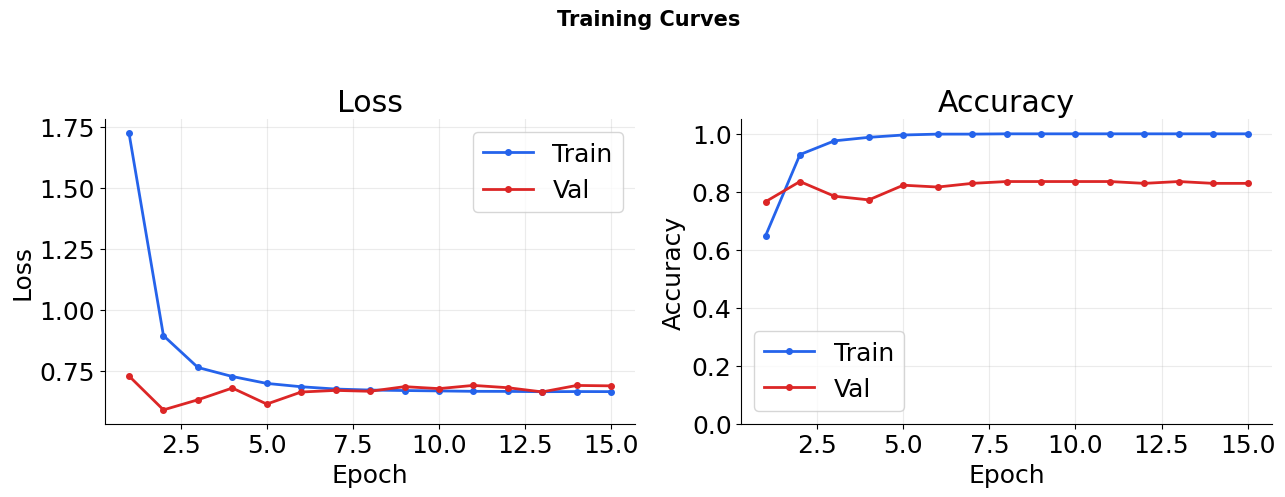

In [22]:
plot_training_results(train_task2)

In [23]:
results_after_t2 = evaluate_all_tasks(
    model            = model_task2,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader, task2_test_loader],
    combined_loaders = [combined_test_loader, combined_test_loader2],
)

  base             -> Acc=0.0047  Loss=3.5252
  task1_only       -> Acc=0.1889  Loss=2.9359
  task2_only       -> Acc=0.8628  Loss=0.6180
  combined_t1      -> Acc=0.0979  Loss=3.2271
  combined_t2      -> Acc=0.3618  Loss=2.3269


Running Inference on Test Set...


  Testing:   0%|          | 0/11 [00:00<?, ?it/s]

Test Accuracy: 0.3618


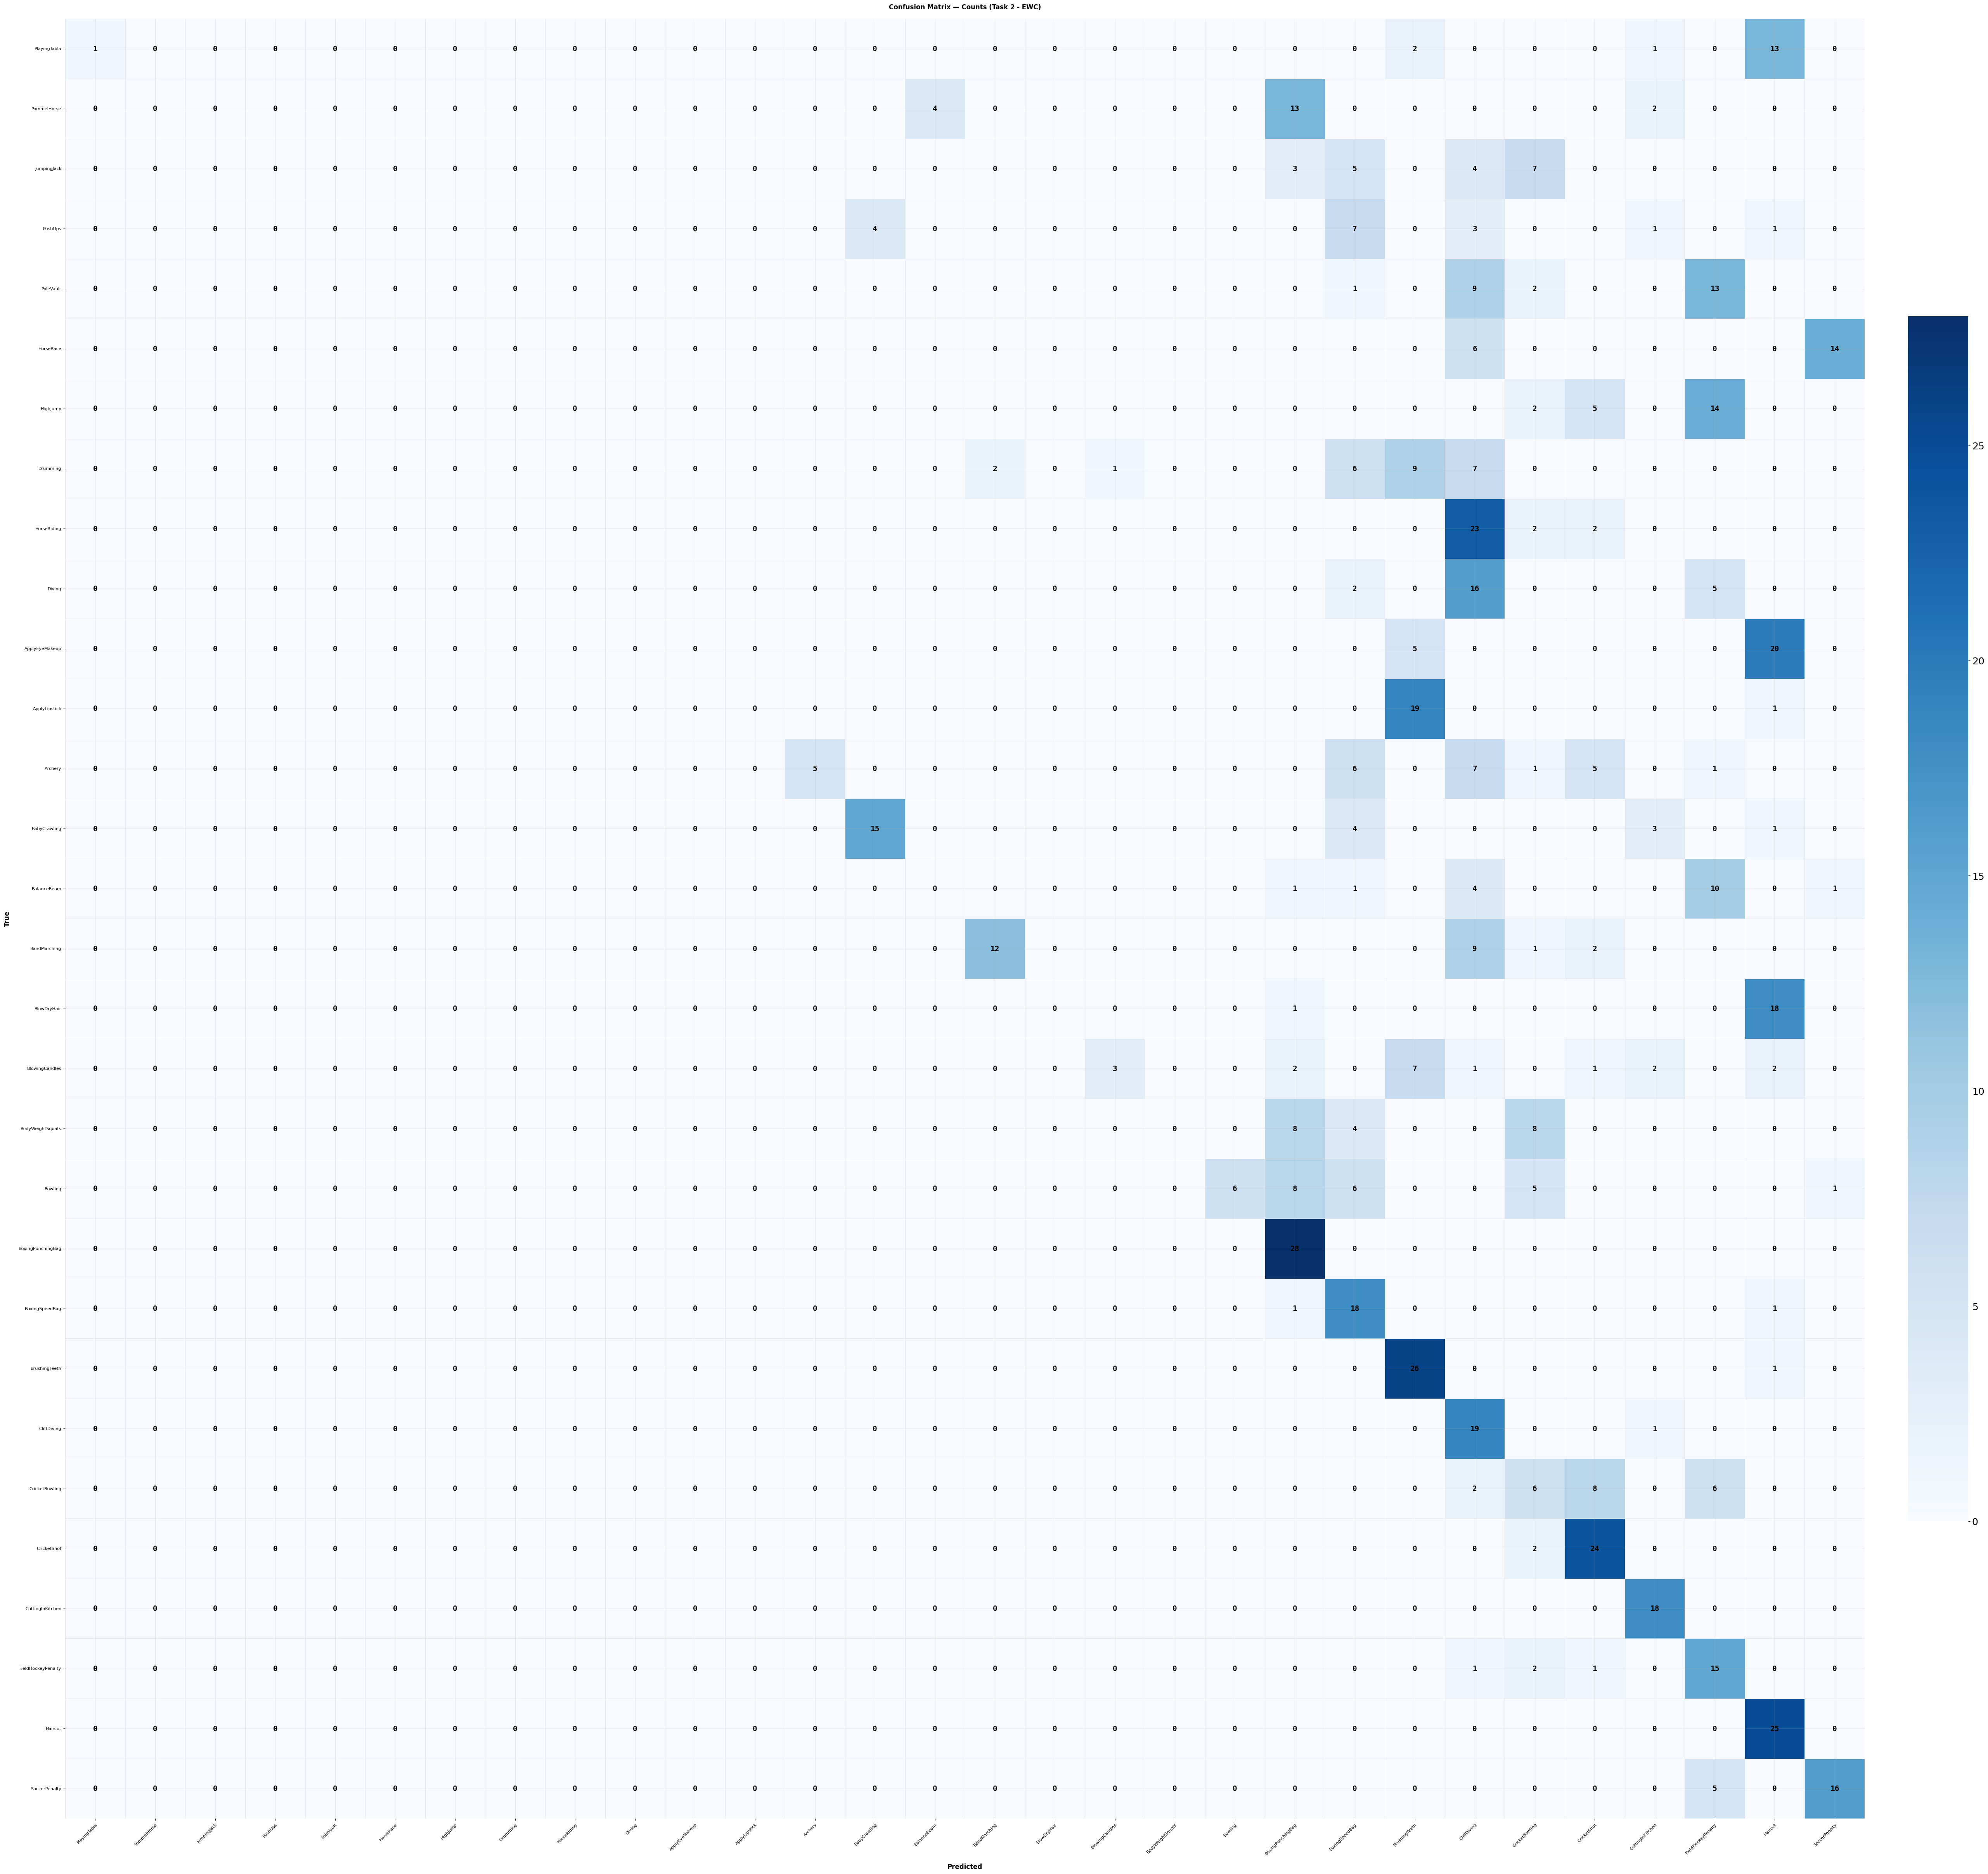

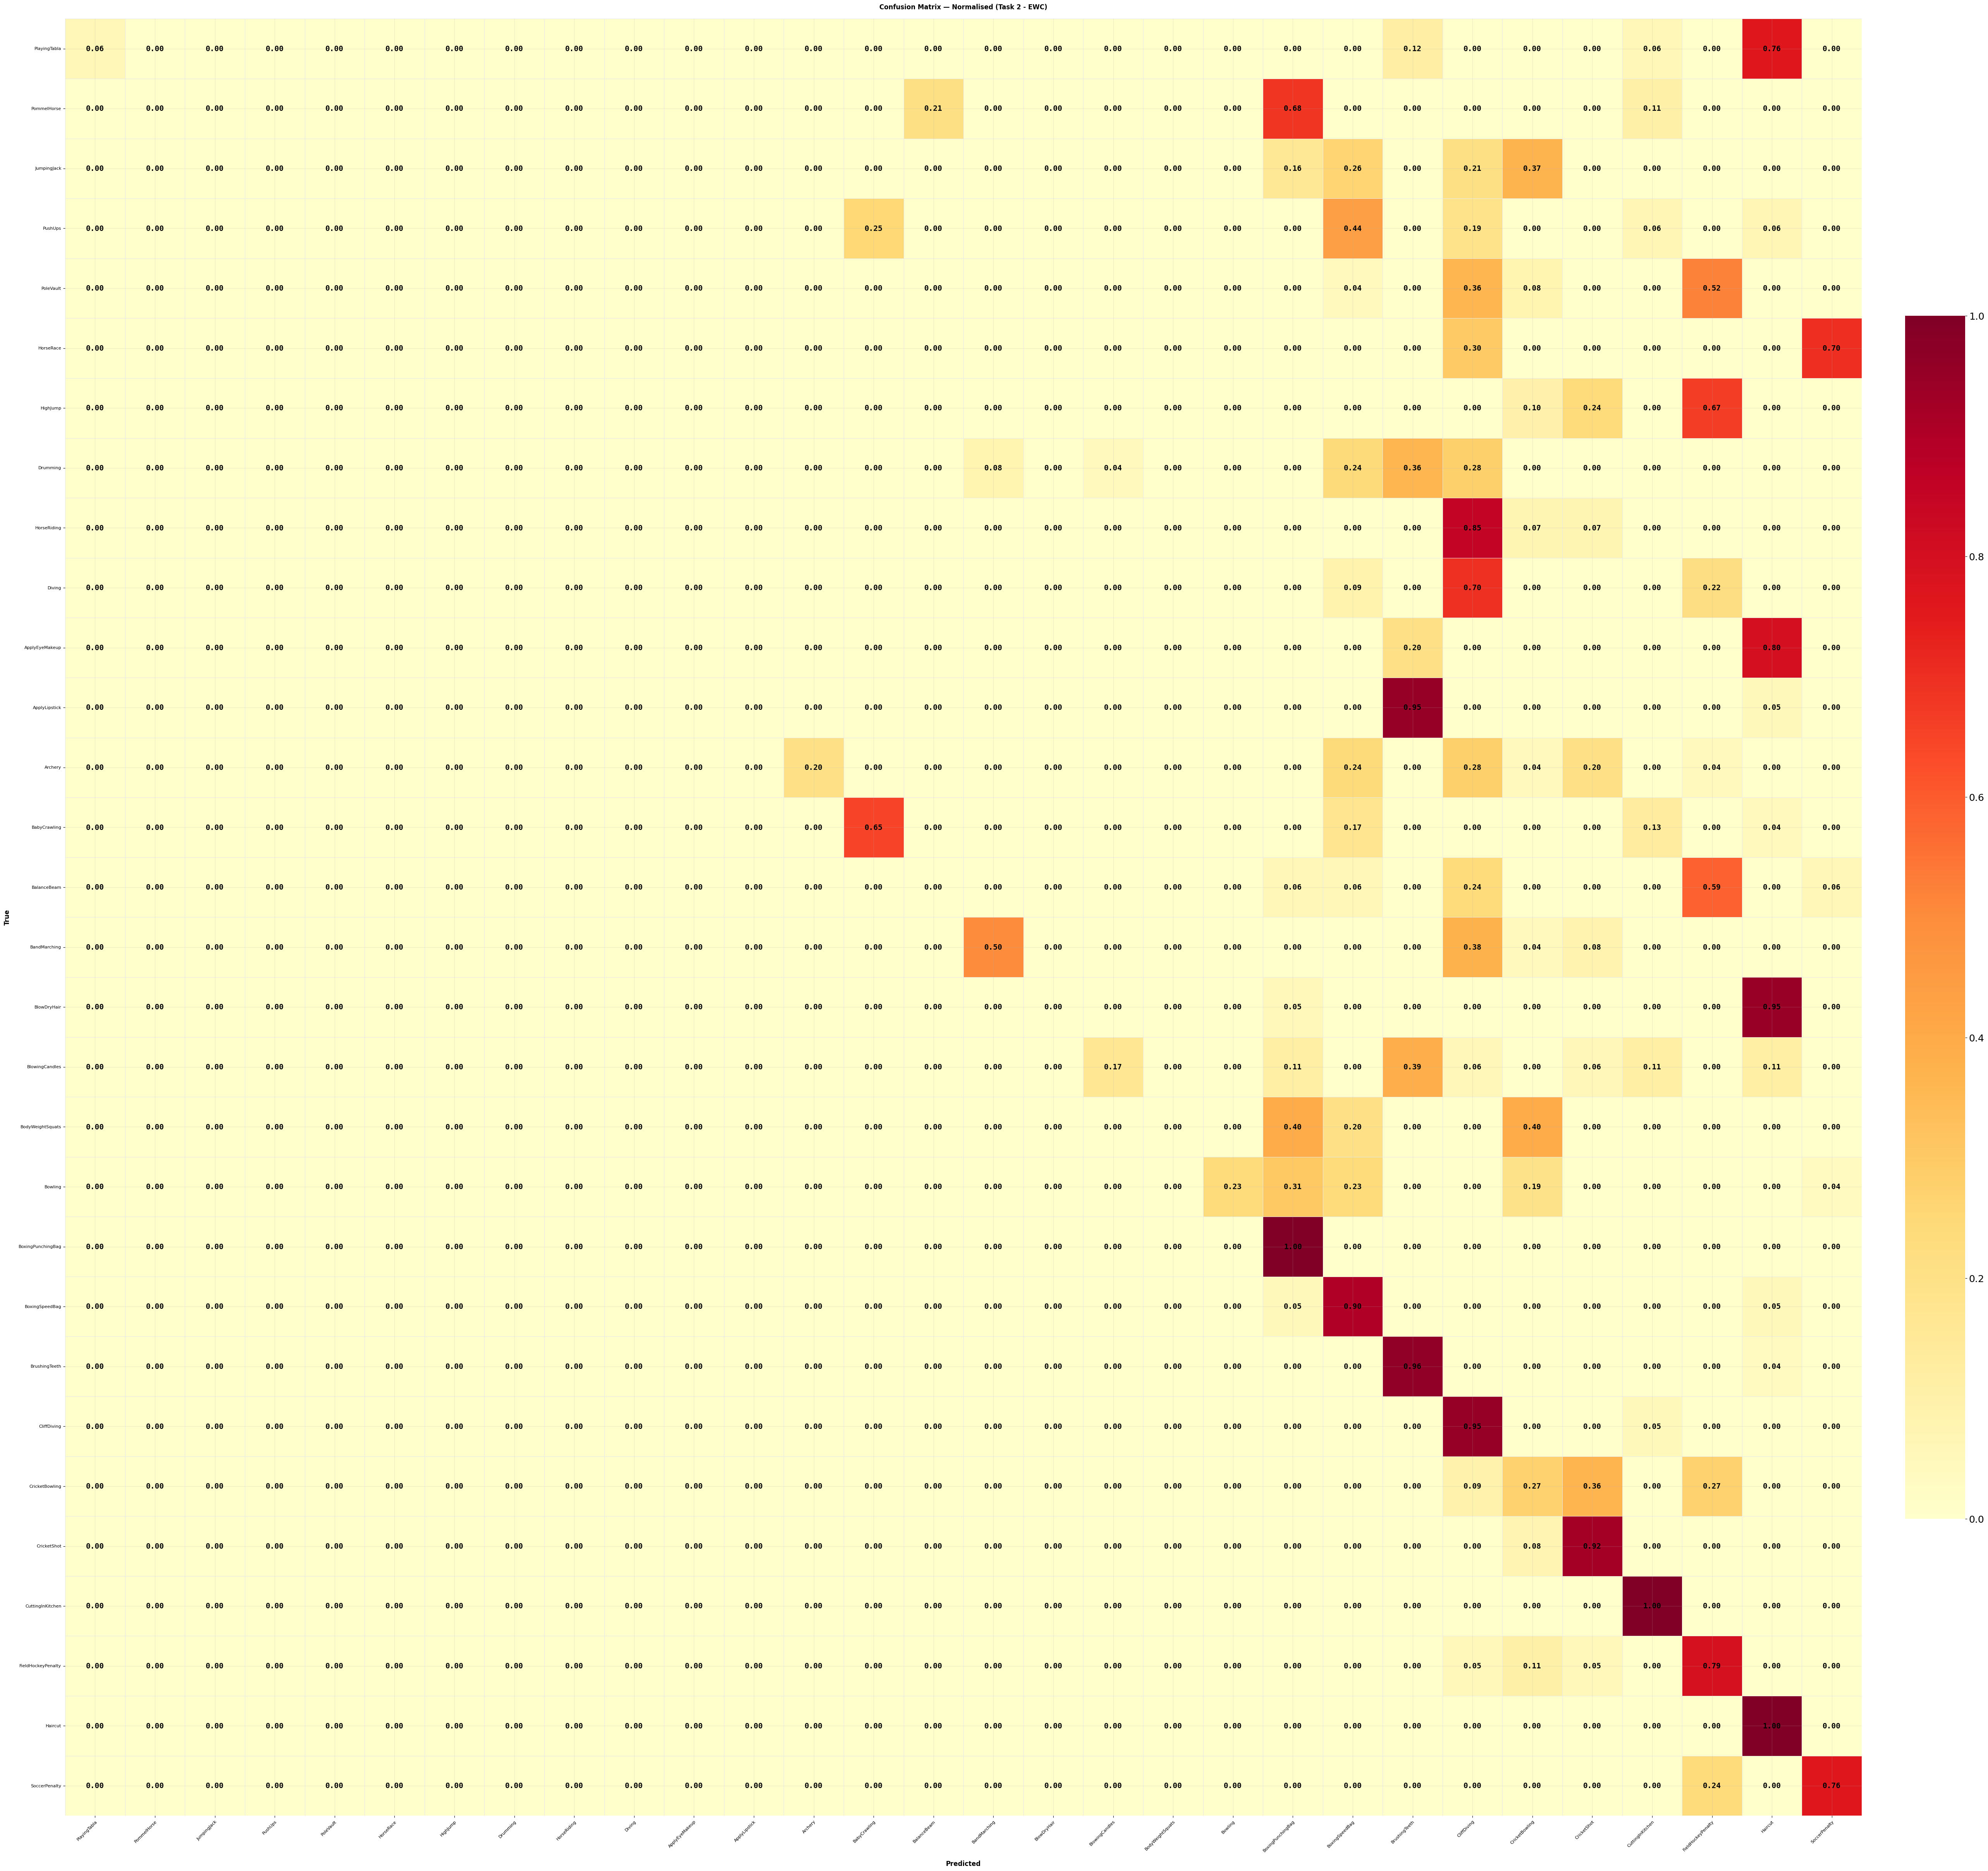

In [24]:
_, all_preds, all_labels = test_model(model_task2, combined_test_loader2, device)

plot_confusion_matrix(
    all_labels, all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    name         = f"Task 2 - {ARM_NAME}",
)

In [25]:
print_detailed_metrics(
    all_labels   = all_labels,
    all_preds    = all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    split_old    = (0, len(cfg.SELECTED_CLASSES)),
    split_new    = (len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST)),
)


METRICS FOR 30 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.3618
  Precision : 0.3088
  Recall    : 0.3618
  F1-Score  : 0.2580

PER-CLASS REPORT 
                    precision    recall  f1-score   support

      PlayingTabla       1.00      0.06      0.11        17
       PommelHorse       0.00      0.00      0.00        19
       JumpingJack       0.00      0.00      0.00        19
           PushUps       0.00      0.00      0.00        16
         PoleVault       0.00      0.00      0.00        25
         HorseRace       0.00      0.00      0.00        20
          HighJump       0.00      0.00      0.00        21
          Drumming       0.00      0.00      0.00        25
       HorseRiding       0.00      0.00      0.00        27
            Diving       0.00      0.00      0.00        23
    ApplyEyeMakeup       0.00      0.00      0.00        25
     ApplyLipstick       0.00      0.00      0.00        20
           Archery       1.00      0.20      0.33        25
     

## **Latent Space**

In [26]:
preds_emb, labels_emb = predict_head(head_task2, CACHE, [0, 1, 2], device)

res_emb = report_accuracy(preds_emb, labels_emb, TASK_CLASSES, TASK_NAMES, class_to_idx,
                          title=f"FINAL - EMBEDDINGS ({ARM_NAME})")


  FINAL - EMBEDDINGS (EWC)
  Base          0.47%   (212 clips, 10 classes)
  Task1        18.89%   (217 clips, 10 classes)
  Task2        86.28%   (226 clips, 10 classes)
  ----------------------------------------------------------
  COMBINED     36.18%   (655 clips, all classes)
  mean/task    35.22%


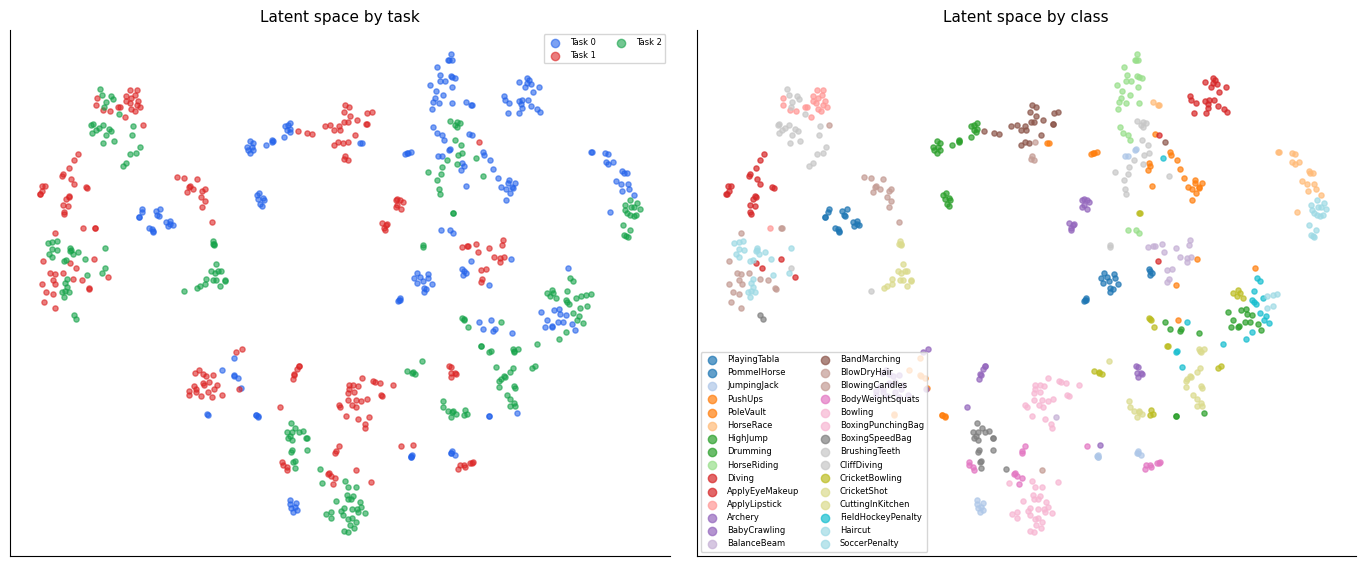

In [27]:
xy, lab = project_head_space(head_task2, CACHE, [0, 1, 2], device, seed=cfg.SEED)
task_of = {class_to_idx[c]: t for t, g in enumerate(TASK_CLASSES) for c in g}

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
plot_latent_space(xy, lab, ALL_CLASSES_LIST, task_of=task_of,
                  title="Latent space by task", ax=ax[0])
plot_latent_space(xy, lab, ALL_CLASSES_LIST,
                  title="Latent space by class", ax=ax[1])
plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/latent_{ARM_KEY}.png", dpi=150, bbox_inches="tight")
plt.show()

## **Evaluation on Real Images**

In [28]:
if not clips_available(TASK_ROOTS, "test"):
    print("Raw clips not found. Re-run the Preprocess cell to evaluate on real images.")
    res_real = None
else:
    backbone = load_frozen_backbone(
        device, ResNet50LSTMTeacher, cfg.RESNET50_PATH,
        hidden_size=cfg.TEACHER_HIDDEN, num_classes=len(cfg.SELECTED_CLASSES),
        dropout_p=cfg.DROPOUT_P, remap_fn=remap_teacher_checkpoint,
    )
    full_model = FullModel(backbone, head_task2, backbone_dim=cfg.BACKBONE_DIM).to(device)

    real_loader = clip_loaders(TASK_ROOTS, TASK_CLASSES, class_to_idx, "test",
                               batch_size=cfg.BATCH_SIZE, num_workers=cfg.NUM_WORKERS)[1]
    preds_real, labels_real = predict(full_model, real_loader, device)

    res_real = report_accuracy(preds_real, labels_real, TASK_CLASSES, TASK_NAMES,
                               class_to_idx, title=f"FINAL - REAL IMAGES ({ARM_NAME})")

  Dropped 53 num_batches_tracked buffer(s).

  FINAL - REAL IMAGES (EWC)
  Base         59.06%   (171 clips, 10 classes)
  Task1        24.85%   (169 clips, 10 classes)
  Task2        87.01%   (177 clips, 10 classes)
  ----------------------------------------------------------
  COMBINED     57.45%   (517 clips, all classes)
  mean/task    56.97%


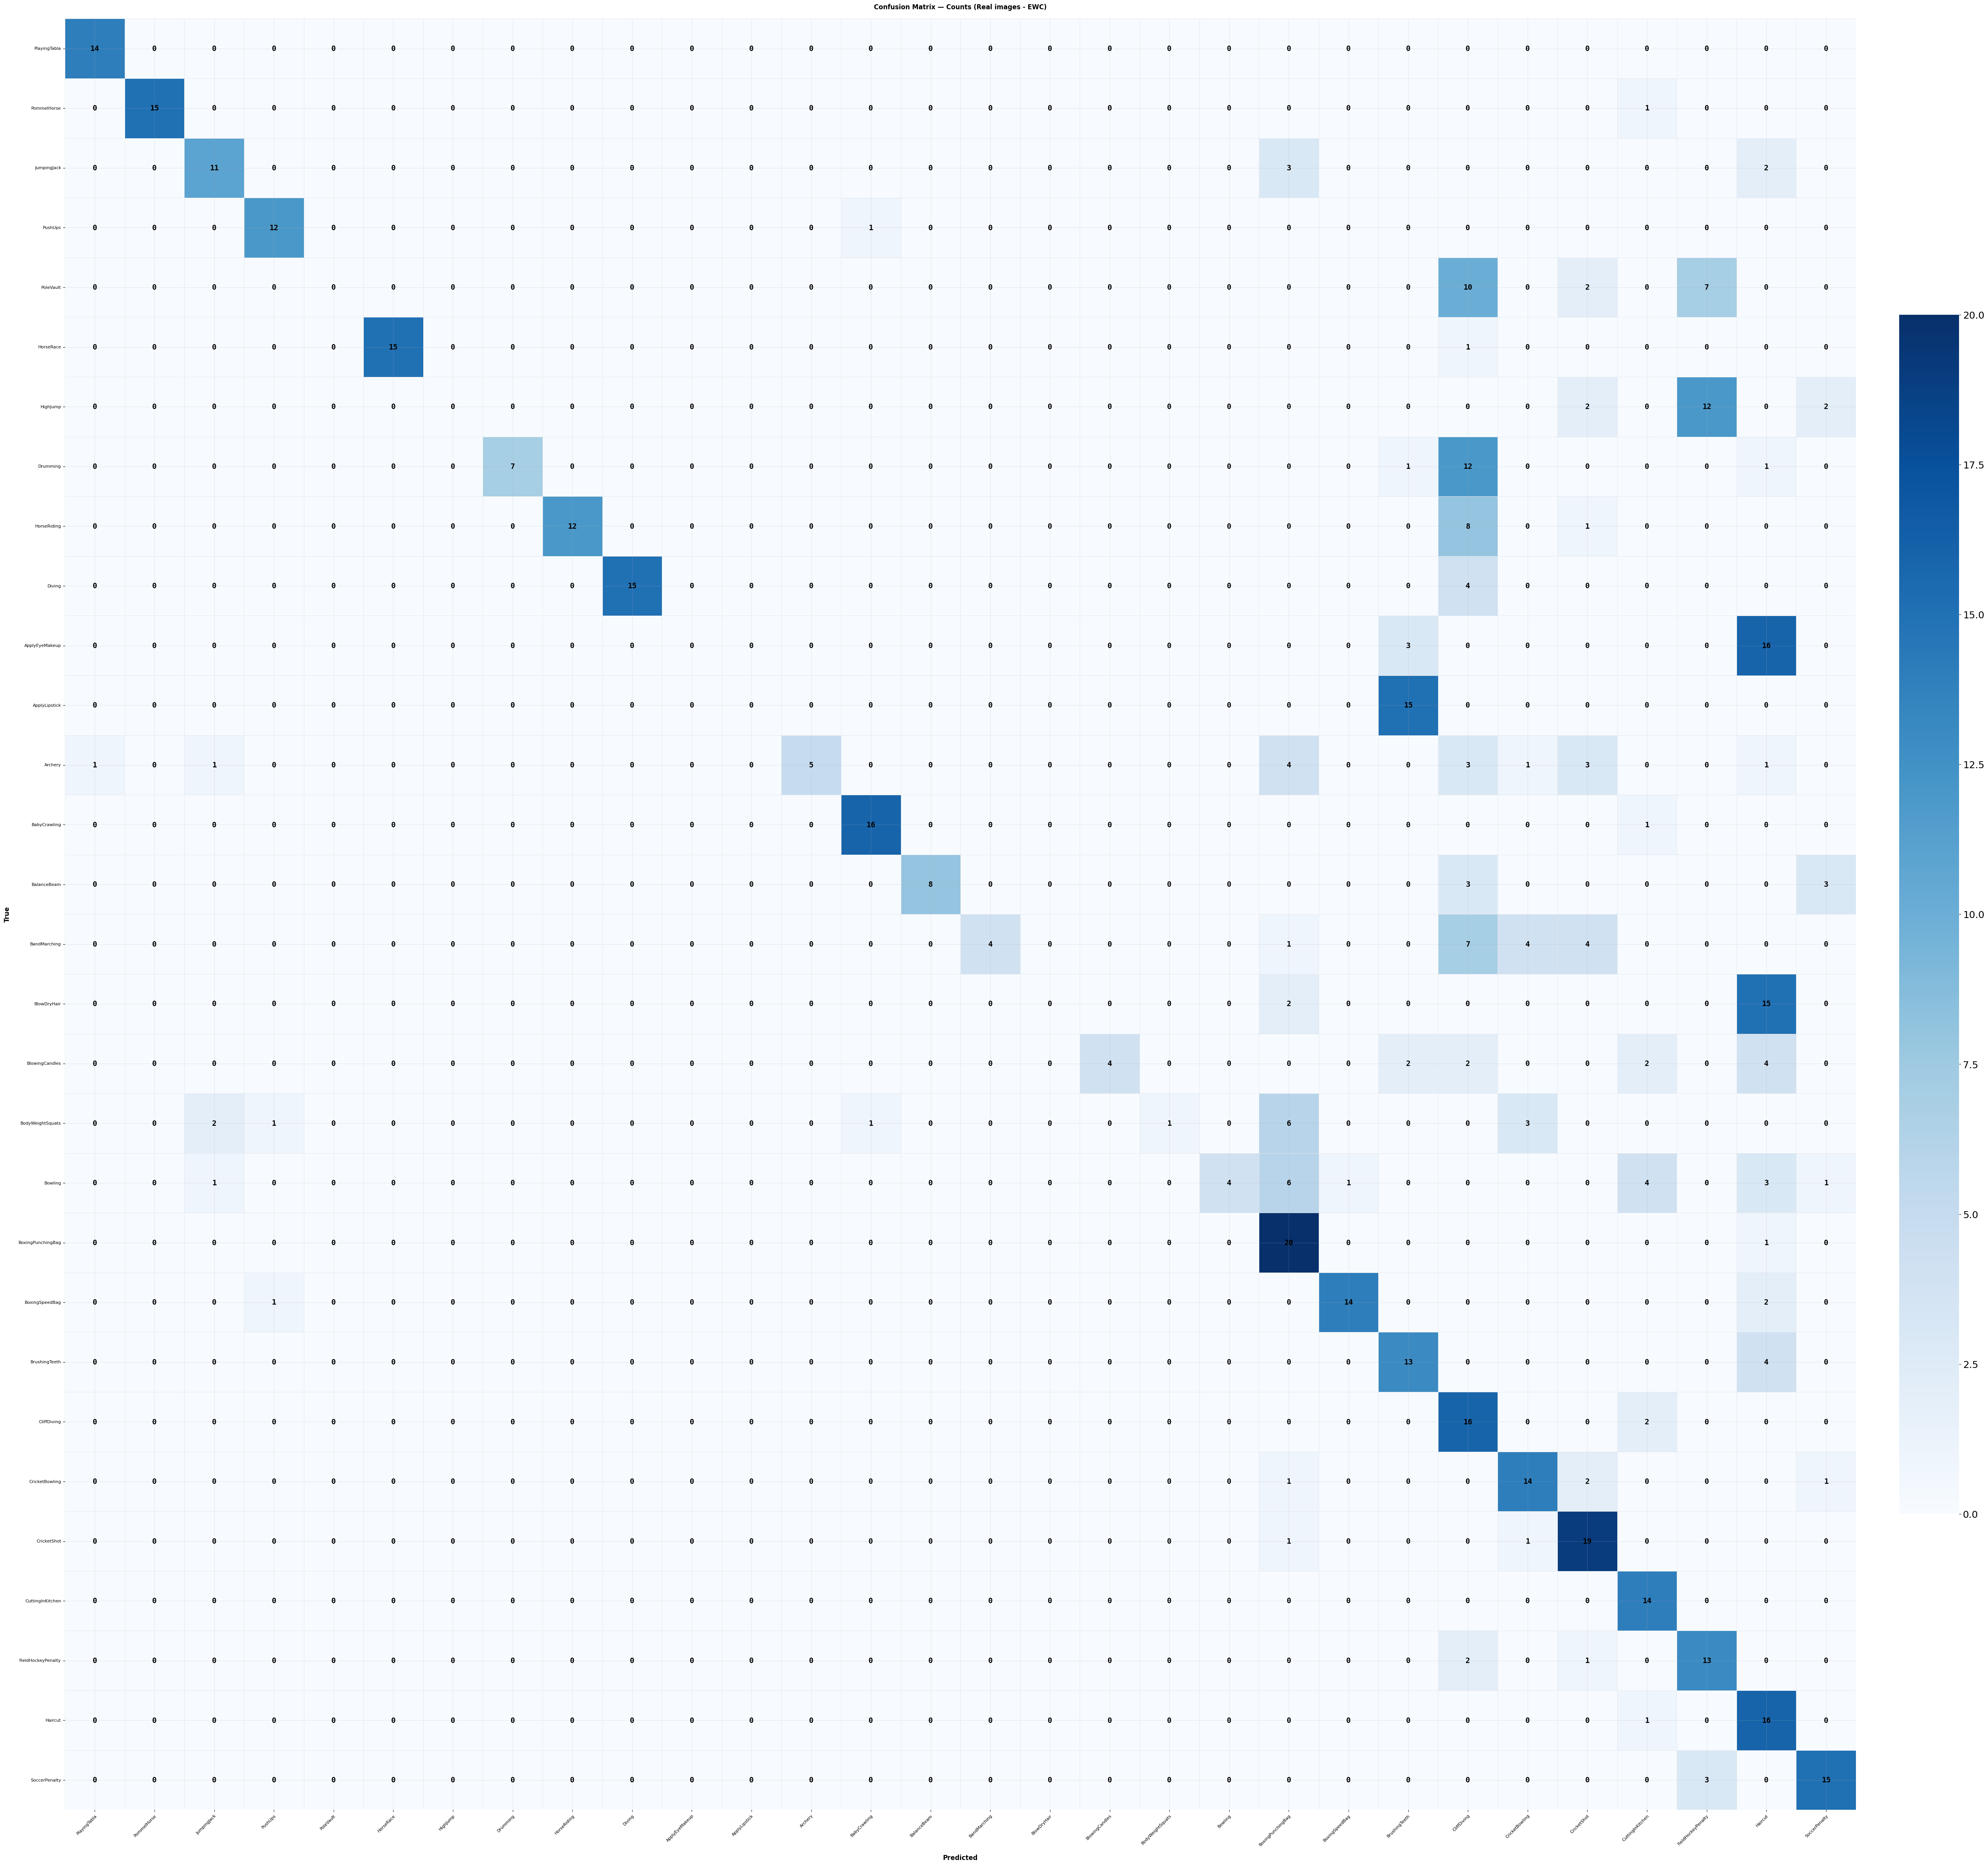

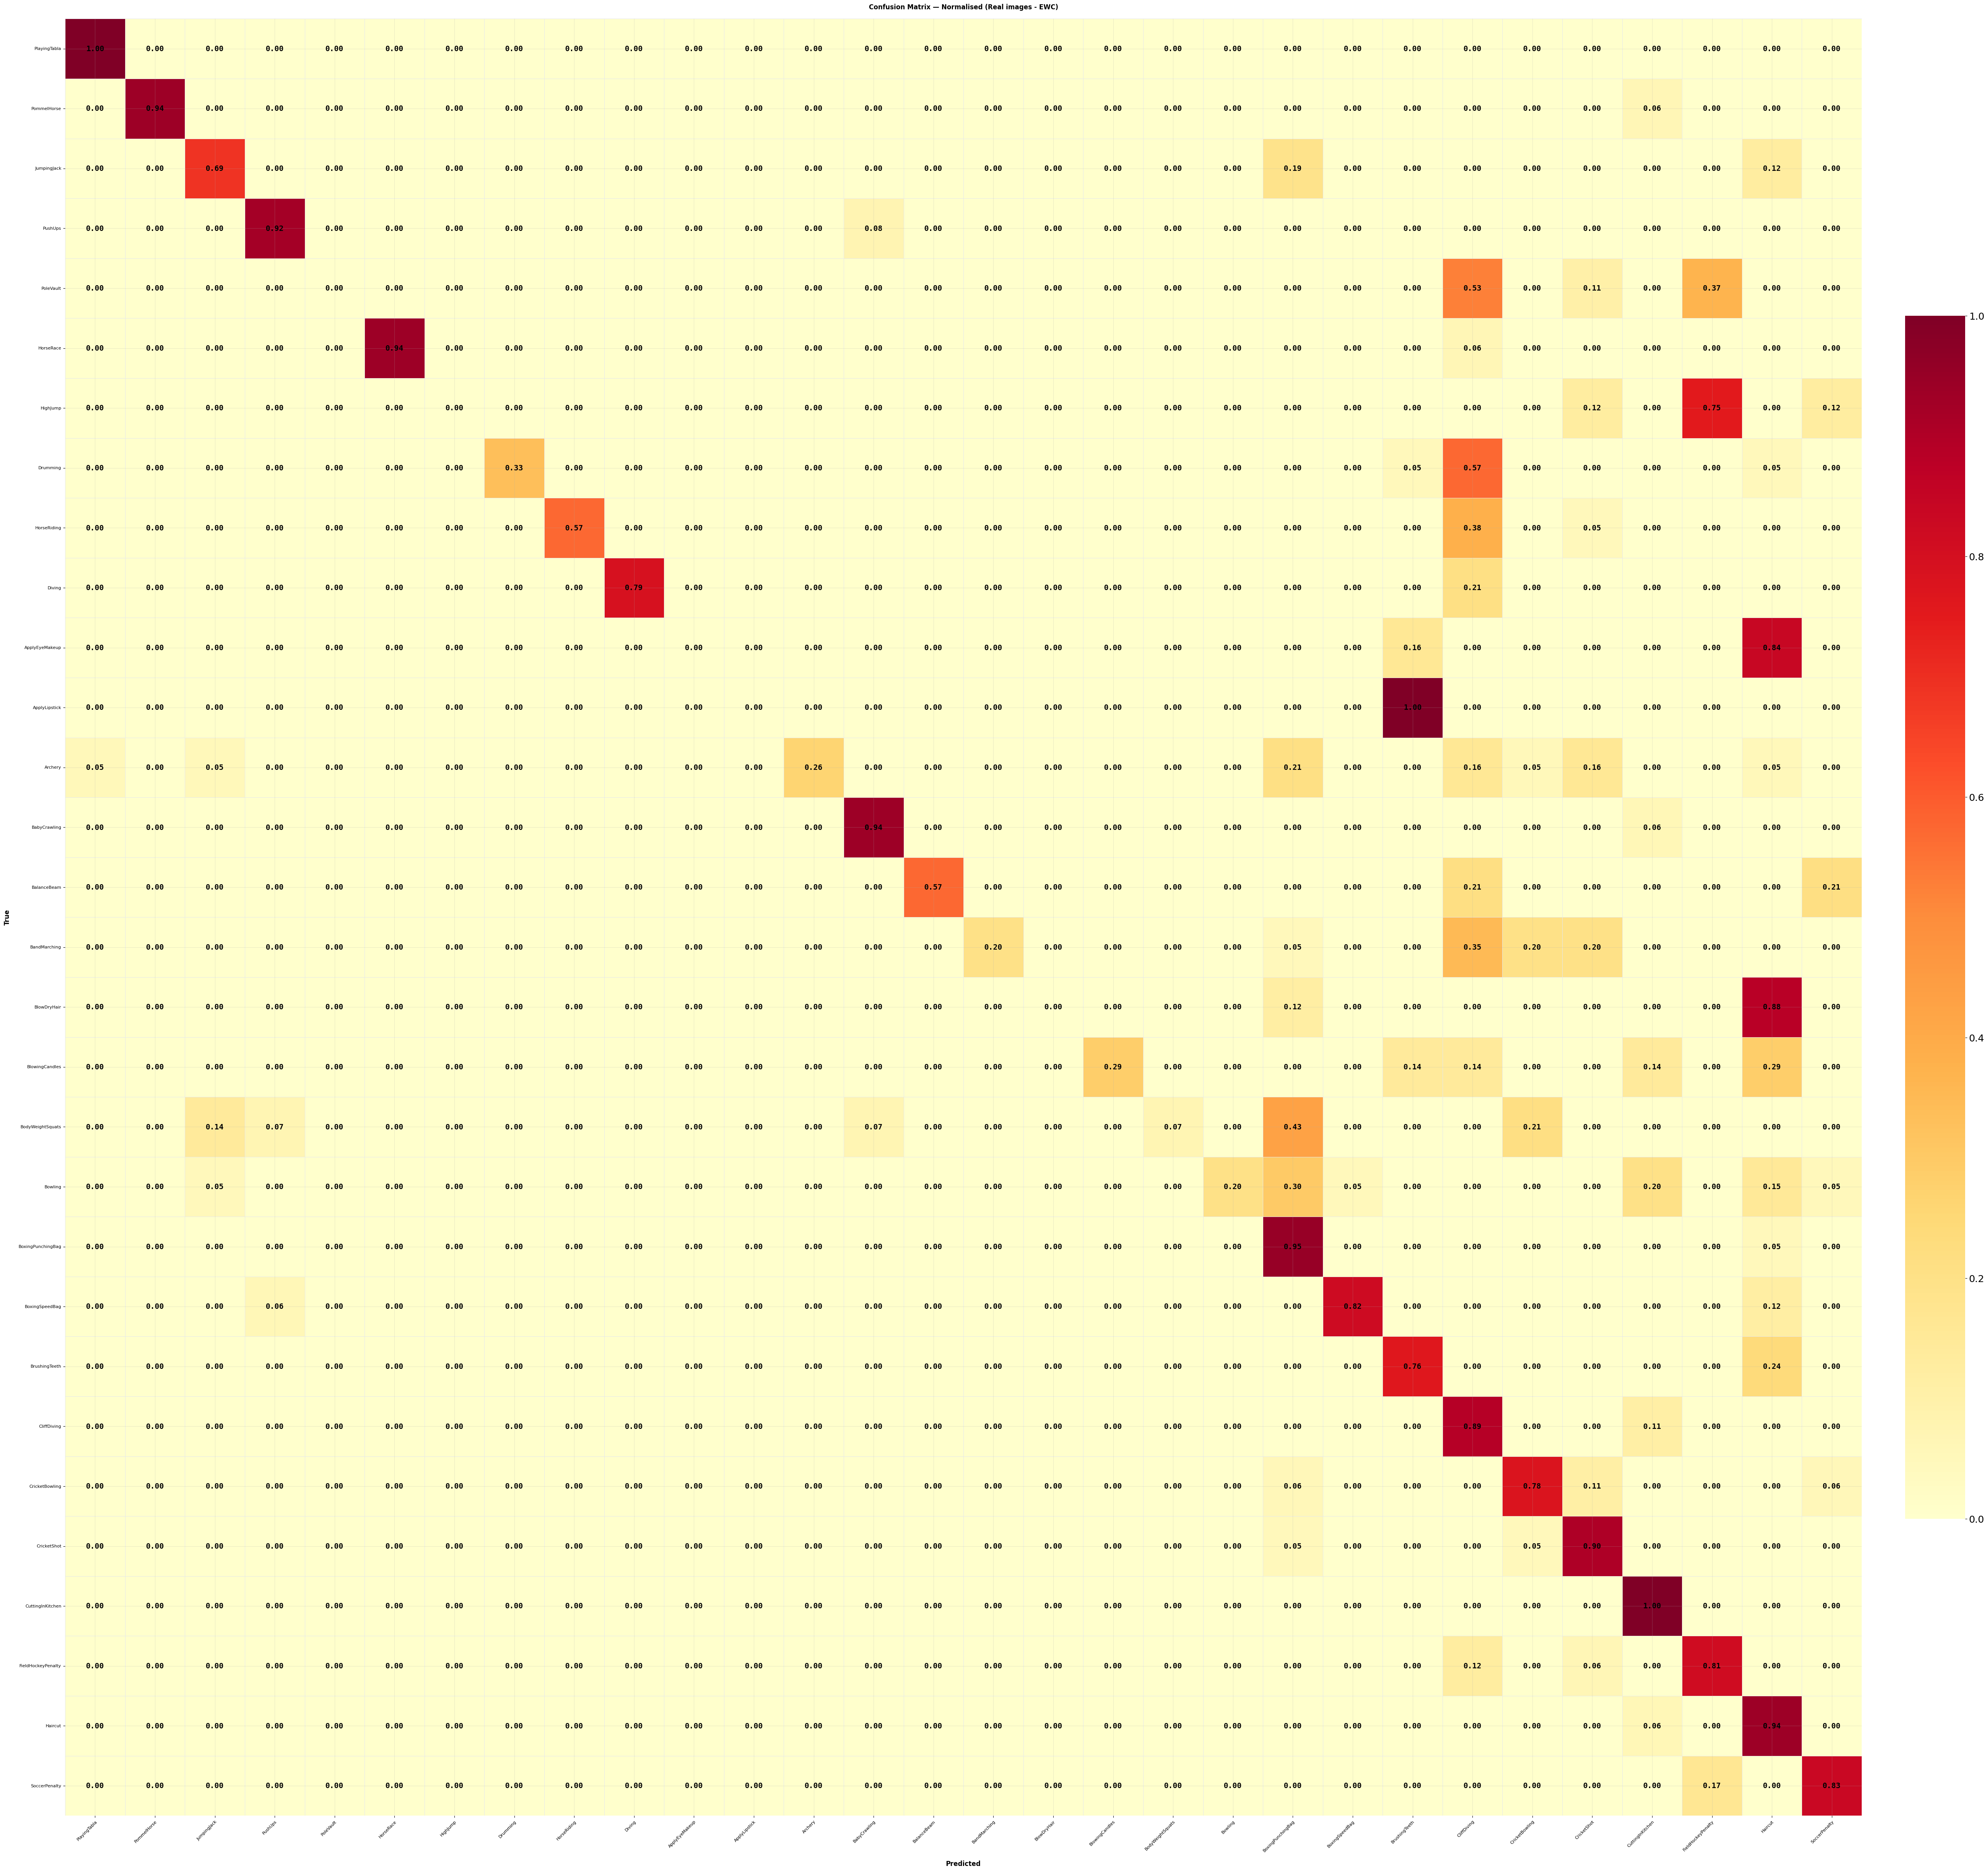


  EMBEDDINGS vs REAL IMAGES
  Split          embeddings   real images     diff
  ----------------------------------------------------------
  Base                0.47%        59.06%  +58.59%
  Task1              18.89%        24.85%   +5.96%
  Task2              86.28%        87.01%   +0.72%
  ----------------------------------------------------------
  COMBINED           36.18%        57.45%  +21.26%


In [29]:
if res_real is not None:
    plot_confusion_matrix(
        labels_real, preds_real,
        num_classes  = len(ALL_CLASSES_LIST),
        classes_list = ALL_CLASSES_LIST,
        name         = f"Real images - {ARM_NAME}",
    )

    compare_embeddings_vs_real(res_emb, res_real, TASK_NAMES)

## **Save**

In [ ]:
# per-task rows, captured before Task 2 mutates head_task1 in place
ROWS = [
    {0: eval_head(head_base, *task_split(CACHE, 0, "test"), device)},
    {0: results_after_t1["base"]["accuracy"],
     1: results_after_t1["task1_only"]["accuracy"]},
    {0: results_after_t2["base"]["accuracy"],
     1: results_after_t2["task1_only"]["accuracy"],
     2: results_after_t2["task2_only"]["accuracy"]},
]
BYTES_PER_CLASS = buffer_bytes_per_class(buffer, 15) if "buffer" in dir() else 0

R, m = save_arm_result(f"{cfg.RESULTS_DIR}/stage1_arm_{ARM_KEY}.json",
                       ARM_NAME, ROWS, TASK_NAMES, BYTES_PER_CLASS,
                       config=ARM_CONFIG, ceiling=None)
cl_report(R, ARM_NAME, TASK_NAMES)
torch.save(head_task2.state_dict(), f"{cfg.CKPT_DIR}/head_{ARM_KEY}.pt")

with open(f"{cfg.RESULTS_DIR}/stage1_final_{ARM_KEY}.json", "w") as f:
    json.dump({"embeddings": res_emb, "real_images": res_real}, f, indent=2, default=float)


EWC: AA=35.22%  BWT=-81.93%  base=0.47%  mem=0 KB/class
Saved -> /content/drive/MyDrive/apai/results/stage1_arm_ewc.json

  CL REPORT — EWC
  After \ On  |   Base |  Task1 |  Task2
  --------------------------------------
  Task 0       | 91.98% |      — |      —
  Task 1       |  8.02% | 91.24% |      —
  Task 2       |  0.47% | 18.89% | 86.28%
  Average Accuracy (AA)  : 35.22%
  Forgetting Measure (F) : 81.93%
  Backward Transfer (BWT): -81.93%
  Forward Transfer  (FWT): +0.00%


: 